In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cryptography.hazmat.primitives.asymmetric import rsa, padding
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.backends import default_backend

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
key_sizes = [512, 1024, 2048, 4096]
rsa_results = []

for size in key_sizes:
    start = time.time()
    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=size,
        backend=default_backend()
    )
    elapsed = time.time() - start
    
    public_key = private_key.public_key()
    
    rsa_results.append({
        'key_size': size,
        'keygen_time': elapsed,
        'public_key_bits': size,
    })
    print(f"RSA-{size}: {elapsed:.4f}s")

ValueError: key_size must be at least 1024-bits.

In [3]:
key_sizes = [1024, 2048, 4096]
rsa_results = []

for size in key_sizes:
    start = time.time()
    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=size,
        backend=default_backend()
    )
    elapsed = time.time() - start
    
    public_key = private_key.public_key()
    
    rsa_results.append({
        'key_size': size,
        'keygen_time': elapsed,
        'public_key_bits': size,
    })
    print(f"RSA-{size}: {elapsed:.4f}s")

RSA-1024: 0.0148s
RSA-2048: 0.0473s
RSA-4096: 0.1058s


In [4]:
message = b"Sensitive data requiring quantum-resistant protection."

for result in rsa_results:
    size = result['key_size']
    
    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=size,
        backend=default_backend()
    )
    public_key = private_key.public_key()
    
    # encryption
    start = time.time()
    ciphertext = public_key.encrypt(
        message,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None
        )
    )
    result['encrypt_time'] = time.time() - start
    
    # decryption
    start = time.time()
    plaintext = private_key.decrypt(
        ciphertext,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None
        )
    )
    result['decrypt_time'] = time.time() - start
    
    print(f"RSA-{size} | encrypt: {result['encrypt_time']:.6f}s | decrypt: {result['decrypt_time']:.6f}s")

RSA-1024 | encrypt: 0.001013s | decrypt: 0.000327s
RSA-2048 | encrypt: 0.000106s | decrypt: 0.001898s
RSA-4096 | encrypt: 0.000142s | decrypt: 0.004598s


In [5]:
import subprocess
subprocess.run(["pip", "install", "kyber-py"], capture_output=True)
print("kyber-py installed.")


kyber-py installed.


In [6]:
from kyber import Kyber512, Kyber768, Kyber1024
print("Kyber loaded successfully.")

ModuleNotFoundError: No module named 'kyber'

In [7]:
from kyber_py.kyber import Kyber512, Kyber768, Kyber1024
print("Kyber loaded successfully.")

Kyber loaded successfully.


In [8]:
kyber_variants = [
    ('Kyber512',  Kyber512),
    ('Kyber768',  Kyber768),
    ('Kyber1024', Kyber1024),
]

kyber_results = []

for name, kyber in kyber_variants:
    # key generation
    start = time.time()
    public_key, private_key = kyber.keygen()
    keygen_time = time.time() - start
    
    # encapsulation (equivalent to encryption)
    start = time.time()
    key, ciphertext = kyber.enc(public_key)
    enc_time = time.time() - start
    
    # decapsulation (equivalent to decryption)
    start = time.time()
    decoded_key = kyber.dec(private_key, ciphertext)
    dec_time = time.time() - start
    
    kyber_results.append({
        'variant': name,
        'keygen_time': keygen_time,
        'enc_time': enc_time,
        'dec_time': dec_time,
        'public_key_bytes': len(public_key),
        'ciphertext_bytes': len(ciphertext),
    })
    
    print(f"{name} | keygen: {keygen_time:.6f}s | enc: {enc_time:.6f}s | dec: {dec_time:.6f}s | pk: {len(public_key)}B | ct: {len(ciphertext)}B")

AttributeError: 'Kyber' object has no attribute 'enc'

In [9]:
kyber_variants = [
    ('Kyber512',  Kyber512),
    ('Kyber768',  Kyber768),
    ('Kyber1024', Kyber1024),
]

kyber_results = []

for name, kyber in kyber_variants:
    # key generation
    start = time.time()
    public_key, private_key = kyber.keygen()
    keygen_time = time.time() - start
    
    # encapsulation (equivalent to encryption)
    start = time.time()
    key, ciphertext = kyber.enc(public_key)
    enc_time = time.time() - start
    
    # decapsulation (equivalent to decryption)
    start = time.time()
    decoded_key = kyber.dec(private_key, ciphertext)
    dec_time = time.time() - start
    
    kyber_results.append({
        'variant': name,
        'keygen_time': keygen_time,
        'enc_time': enc_time,
        'dec_time': dec_time,
        'public_key_bytes': len(public_key),
        'ciphertext_bytes': len(ciphertext),
    })
    
    print(f"{name} | keygen: {keygen_time:.6f}s | enc: {enc_time:.6f}s | dec: {dec_time:.6f}s | pk: {len(public_key)}B | ct: {len(ciphertext)}B")

AttributeError: 'Kyber' object has no attribute 'enc'

In [10]:
print(dir(Kyber512))

['M', 'R', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_cpapke_dec', '_cpapke_enc', '_cpapke_keygen', '_g', '_generate_error_vector', '_generate_matrix_from_seed', '_generate_polynomial', '_h', '_kdf', '_prf', '_unpack_secret_key', '_xof', 'decaps', 'du', 'dv', 'encaps', 'eta_1', 'eta_2', 'k', 'keygen', 'random_bytes', 'set_drbg_seed']


In [11]:
kyber_variants = [
    ('Kyber512',  Kyber512),
    ('Kyber768',  Kyber768),
    ('Kyber1024', Kyber1024),
]

kyber_results = []

for name, kyber in kyber_variants:
    start = time.time()
    public_key, private_key = kyber.keygen()
    keygen_time = time.time() - start
    
    start = time.time()
    key, ciphertext = kyber.encaps(public_key)
    enc_time = time.time() - start
    
    start = time.time()
    decoded_key = kyber.decaps(private_key, ciphertext)
    dec_time = time.time() - start
    
    kyber_results.append({
        'variant': name,
        'keygen_time': keygen_time,
        'enc_time': enc_time,
        'dec_time': dec_time,
        'public_key_bytes': len(public_key),
        'ciphertext_bytes': len(ciphertext),
    })
    
    print(f"{name} | keygen: {keygen_time:.6f}s | enc: {enc_time:.6f}s | dec: {dec_time:.6f}s | pk: {len(public_key)}B | ct: {len(ciphertext)}B")

Kyber512 | keygen: 0.003218s | enc: 0.005059s | dec: 0.010692s | pk: 800B | ct: 768B
Kyber768 | keygen: 0.005486s | enc: 0.008966s | dec: 0.010741s | pk: 1184B | ct: 1088B
Kyber1024 | keygen: 0.008974s | enc: 0.010894s | dec: 0.010902s | pk: 1568B | ct: 1568B


In [12]:
df_rsa = pd.DataFrame(rsa_results)
df_kyber = pd.DataFrame(kyber_results)

# coeficiente de crescimento RSA (decrypt)
decrypt_times = df_rsa['decrypt_time'].values
key_sizes = df_rsa['key_size'].values

coeficientes = []
for i in range(1, len(decrypt_times)):
    ratio_time = decrypt_times[i] / decrypt_times[i-1]
    ratio_key  = key_sizes[i] / key_sizes[i-1]
    coef = ratio_time / ratio_key
    coeficientes.append({
        'transition': f"RSA-{key_sizes[i-1]} → RSA-{key_sizes[i]}",
        'key_ratio': ratio_key,
        'time_ratio': round(ratio_time, 4),
        'growth_coefficient': round(coef, 4)
    })

df_coef = pd.DataFrame(coeficientes)
print("RSA Decryption Growth Coefficient:")
print(df_coef.to_string(index=False))

RSA Decryption Growth Coefficient:
         transition  key_ratio  time_ratio  growth_coefficient
RSA-1024 → RSA-2048        2.0      5.8074              2.9037
RSA-2048 → RSA-4096        2.0      2.4221              1.2111


FileNotFoundError: [Errno 2] No such file or directory: 'docs/performance_comparison.png'

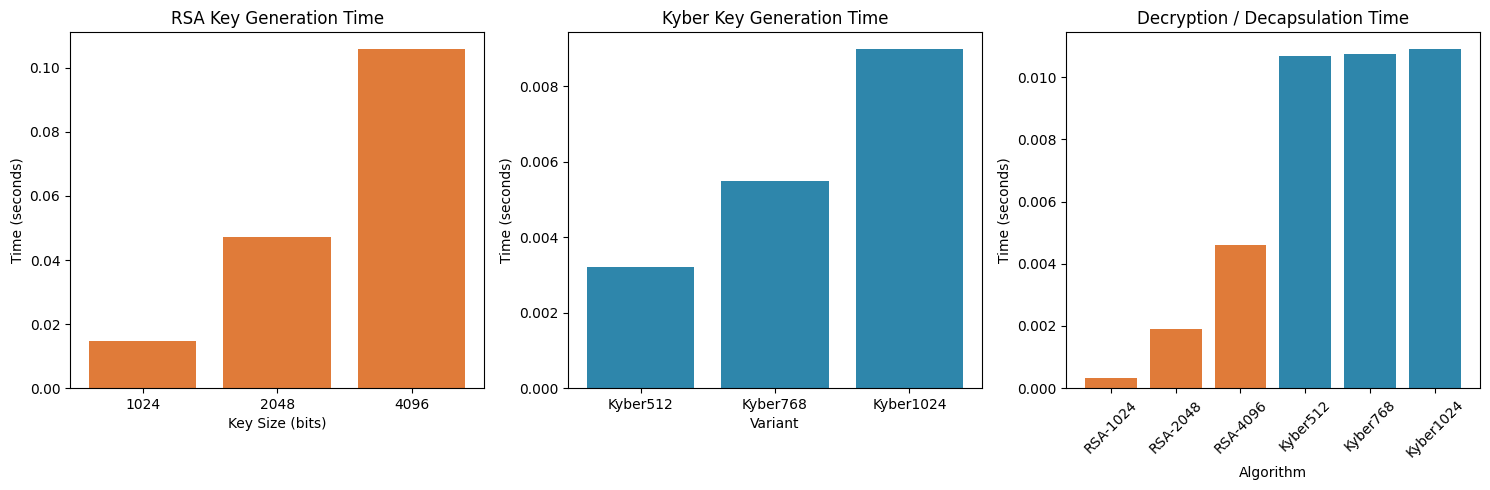

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# gráfico 1: RSA keygen time
axes[0].bar([str(s) for s in df_rsa['key_size']], 
            df_rsa['keygen_time'], color='#E07B39')
axes[0].set_title('RSA Key Generation Time')
axes[0].set_xlabel('Key Size (bits)')
axes[0].set_ylabel('Time (seconds)')

# gráfico 2: Kyber keygen time
axes[1].bar(df_kyber['variant'], 
            df_kyber['keygen_time'], color='#2E86AB')
axes[1].set_title('Kyber Key Generation Time')
axes[1].set_xlabel('Variant')
axes[1].set_ylabel('Time (seconds)')

# gráfico 3: RSA decrypt vs Kyber decaps
rsa_labels = [f"RSA-{s}" for s in df_rsa['key_size']]
kyber_labels = list(df_kyber['variant'])
all_labels = rsa_labels + kyber_labels
all_times = list(df_rsa['decrypt_time']) + list(df_kyber['dec_time'])
colors = ['#E07B39']*3 + ['#2E86AB']*3

axes[2].bar(all_labels, all_times, color=colors)
axes[2].set_title('Decryption / Decapsulation Time')
axes[2].set_xlabel('Algorithm')
axes[2].set_ylabel('Time (seconds)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('docs/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [14]:
mkdir docs


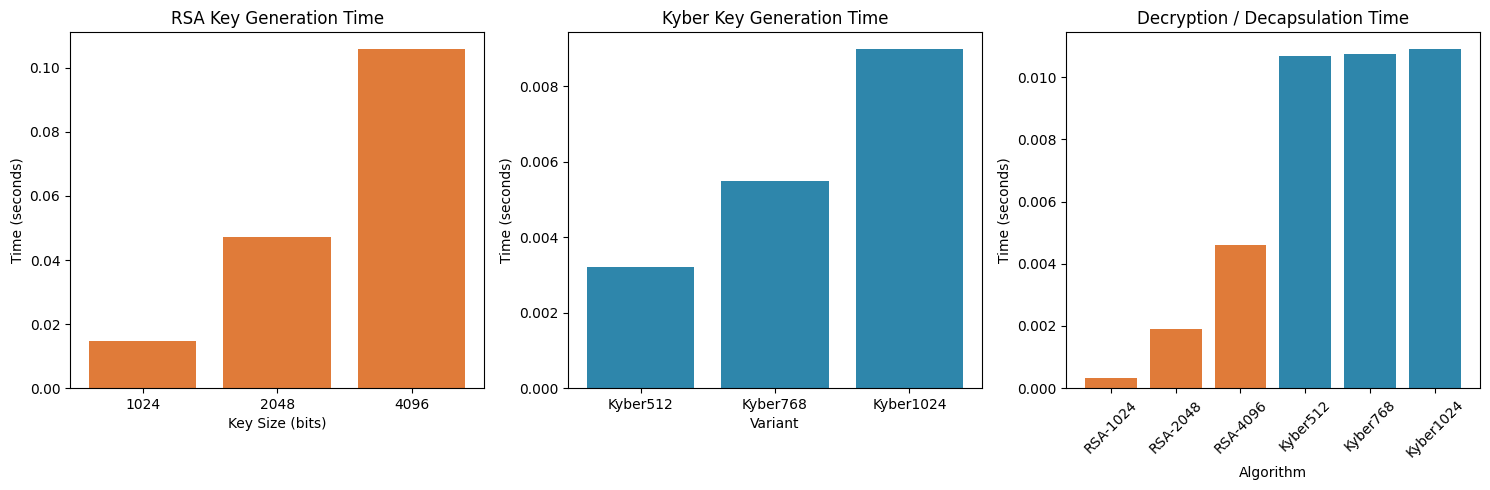

Chart saved.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# gráfico 1: RSA keygen time
axes[0].bar([str(s) for s in df_rsa['key_size']], 
            df_rsa['keygen_time'], color='#E07B39')
axes[0].set_title('RSA Key Generation Time')
axes[0].set_xlabel('Key Size (bits)')
axes[0].set_ylabel('Time (seconds)')

# gráfico 2: Kyber keygen time
axes[1].bar(df_kyber['variant'], 
            df_kyber['keygen_time'], color='#2E86AB')
axes[1].set_title('Kyber Key Generation Time')
axes[1].set_xlabel('Variant')
axes[1].set_ylabel('Time (seconds)')

# gráfico 3: RSA decrypt vs Kyber decaps
rsa_labels = [f"RSA-{s}" for s in df_rsa['key_size']]
kyber_labels = list(df_kyber['variant'])
all_labels = rsa_labels + kyber_labels
all_times = list(df_rsa['decrypt_time']) + list(df_kyber['dec_time'])
colors = ['#E07B39']*3 + ['#2E86AB']*3

axes[2].bar(all_labels, all_times, color=colors)
axes[2].set_title('Decryption / Decapsulation Time')
axes[2].set_xlabel('Algorithm')
axes[2].set_ylabel('Time (seconds)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('docs/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [16]:
plt.savefig('../docs/performance_comparison.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

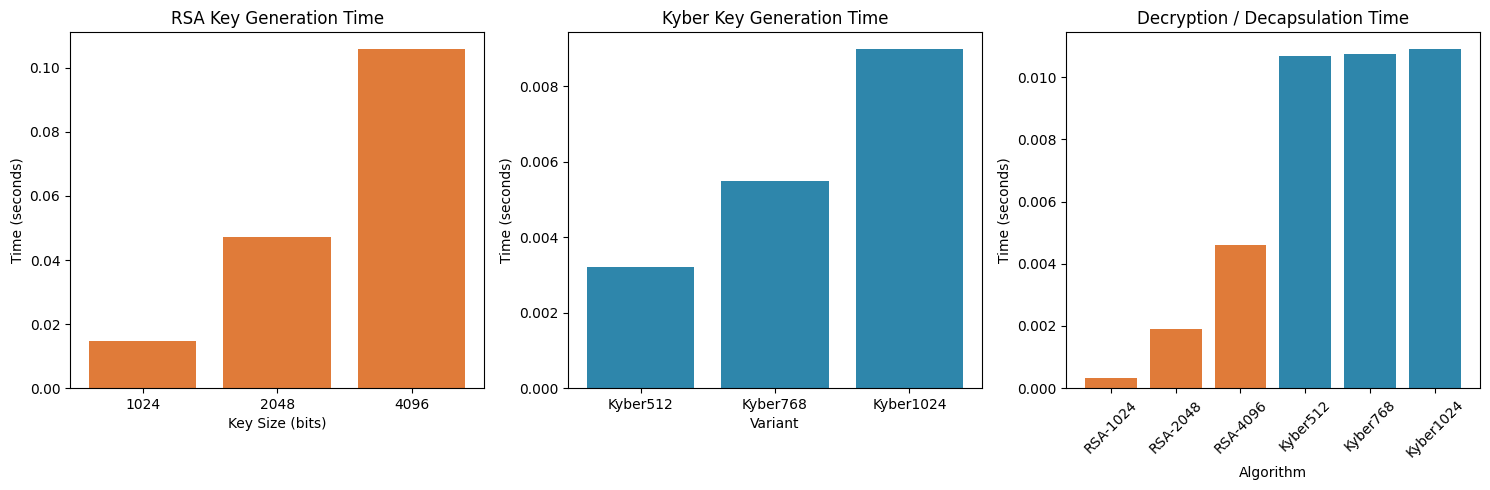

Chart saved.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar([str(s) for s in df_rsa['key_size']], 
            df_rsa['keygen_time'], color='#E07B39')
axes[0].set_title('RSA Key Generation Time')
axes[0].set_xlabel('Key Size (bits)')
axes[0].set_ylabel('Time (seconds)')

axes[1].bar(df_kyber['variant'], 
            df_kyber['keygen_time'], color='#2E86AB')
axes[1].set_title('Kyber Key Generation Time')
axes[1].set_xlabel('Variant')
axes[1].set_ylabel('Time (seconds)')

rsa_labels = [f"RSA-{s}" for s in df_rsa['key_size']]
kyber_labels = list(df_kyber['variant'])
all_labels = rsa_labels + kyber_labels
all_times = list(df_rsa['decrypt_time']) + list(df_kyber['dec_time'])
colors = ['#E07B39']*3 + ['#2E86AB']*3

axes[2].bar(all_labels, all_times, color=colors)
axes[2].set_title('Decryption / Decapsulation Time')
axes[2].set_xlabel('Algorithm')
axes[2].set_ylabel('Time (seconds)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../docs/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")